In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# 1. Import library

In [59]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,accuracy_score
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import GridSearchCV,StratifiedKFold,RandomizedSearchCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression,SGDClassifier

import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import loguniform

# 2. Loading dataset

In [60]:
train =pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
train_df =train.copy()
test =pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
test_df =test.copy()
sample =pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')


# 3.EDA

## I. EDA for train data

In [61]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [62]:
train.shape

(198000, 15)

In [63]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [64]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [65]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [66]:
train['comment'] = train['comment'].astype(str)
(train['comment'].str.strip() == "").sum()

np.int64(0)

In [67]:
train['char_len'] = train['comment'].str.len()
train['word_len'] = train['comment'].str.split().apply(len)

In [68]:
train['race'].unique()

array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

In [69]:
train['religion'].unique()

array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

In [70]:
train['gender'].unique()

array([nan, 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

In [71]:
train['label'].unique()

array([2, 0, 1, 3])

In [72]:
(train['comment'].str.strip() == "").sum()
# removing leading and trailing space and cheking if there is any empty str

np.int64(0)

In [73]:
words = " ".join(train['comment']).split()
Counter(words).most_common(20)

[('the', 465333),
 ('to', 285853),
 ('and', 237619),
 ('of', 225011),
 ('a', 209607),
 ('is', 165883),
 ('in', 139398),
 ('that', 127653),
 ('for', 98421),
 ('I', 90956),
 ('you', 85196),
 ('are', 83310),
 ('not', 66845),
 ('be', 66814),
 ('have', 64902),
 ('it', 63988),
 ('on', 62301),
 ('with', 61843),
 ('as', 53344),
 ('they', 52162)]

## II. EDA for test data

In [74]:
test.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [75]:
test.shape

(102000, 14)

In [76]:
test.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


In [77]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [78]:
test.isnull().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [79]:
(test['comment'].str.strip() == "").sum()

np.int64(0)

In [80]:
test['char_len'] = test['comment'].str.len()
test['word_len'] = test['comment'].str.split().apply(len)

In [81]:
words = " ".join(test['comment']).split()
Counter(words).most_common(20)

[('the', 238439),
 ('to', 148013),
 ('and', 122414),
 ('of', 115401),
 ('a', 108792),
 ('is', 85480),
 ('in', 72069),
 ('that', 65180),
 ('for', 51324),
 ('I', 47014),
 ('you', 43692),
 ('are', 42849),
 ('be', 35171),
 ('not', 34991),
 ('have', 33573),
 ('it', 33269),
 ('on', 32230),
 ('with', 31788),
 ('as', 27328),
 ('they', 26816)]

# Data Visualization

<Axes: xlabel='label', ylabel='count'>

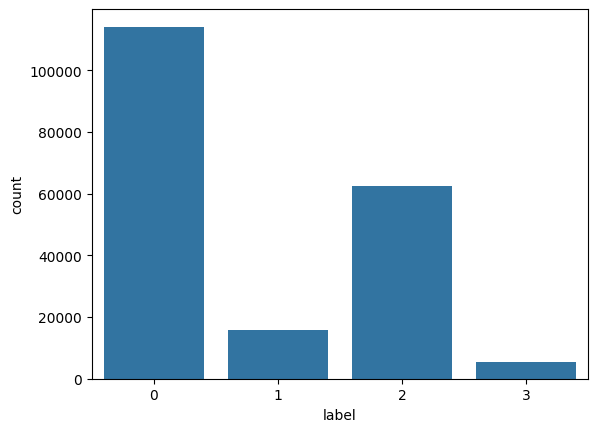

In [82]:
sns.countplot(x=train['label'])

### label 0 has highest count whereas lebel 3 has lowest count

<Axes: xlabel='religion', ylabel='count'>

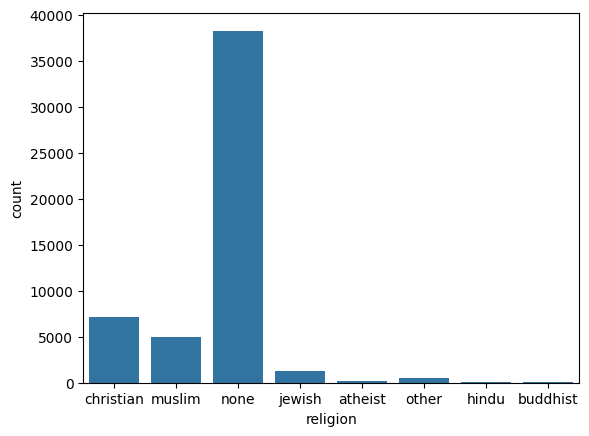

In [83]:
sns.countplot(x=train['religion'])

### The 'none' category is the most frequent value. It has a count of nearly 38,000, which is more than all other categories (Christian, Muslim, Jewish, etc.) combined

<Axes: xlabel='gender', ylabel='count'>

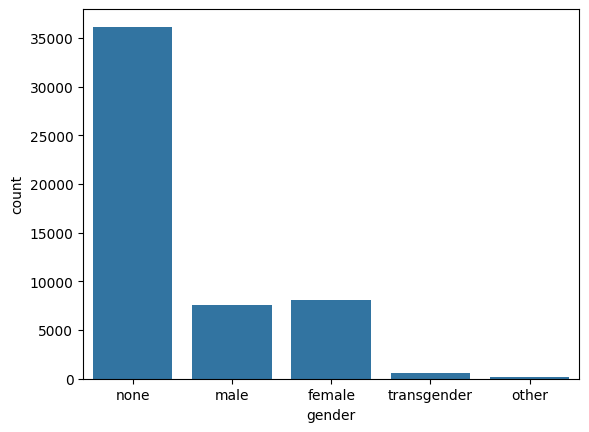

In [84]:
sns.countplot(x=train['gender'])

### The 'none' category is the most frequent value. It has a count of nearly 36,000, which is more than all other categories combined

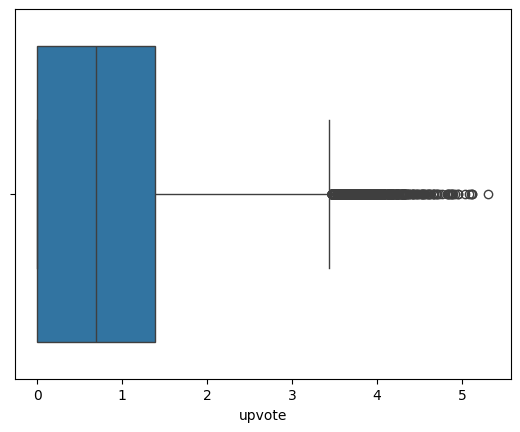

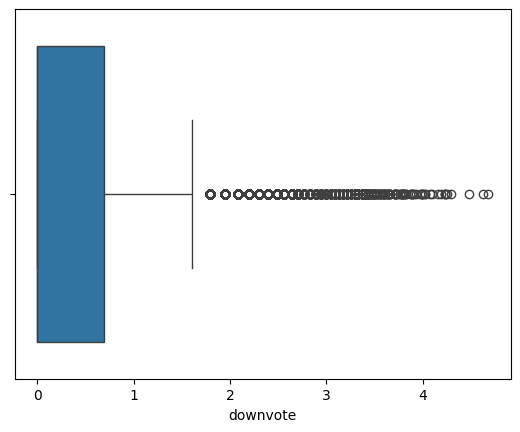

In [85]:
sns.boxplot(x=np.log1p(train['upvote']))
plt.show()
sns.boxplot(x=np.log1p(train['downvote']))
plt.show()

### Finding : After applying log1p transformation on upvote and downvote, the distribution becomes less skewed. 
### However, some outliers are still present, indicating a long-tail distribution. 
### The transformation helps stabilize variance and makes the data more suitable for modeling.

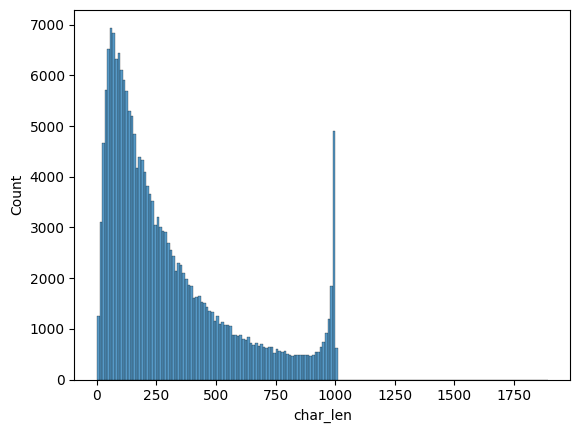

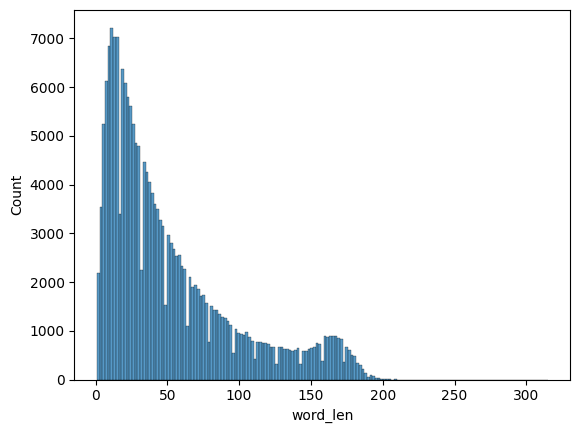

In [86]:
sns.histplot(train['char_len'])
plt.show()
sns.histplot(train['word_len'])
plt.show()

### The character length distribution shows a noticeable spike around ~1000 characters, suggesting that many comments are truncated at a fixed maximum length. However, a similar spike is not observed in the word length distribution, indicating that comments with the same character length can have varying numbers of words.

### Additionally, some comments have very high character length but low word count, implying the presence of long continuous strings (possibly gibberish or spam-like content with few spaces). This highlights variability in text structure and suggests that features like average word length or text quality indicators may be useful.

<Axes: >

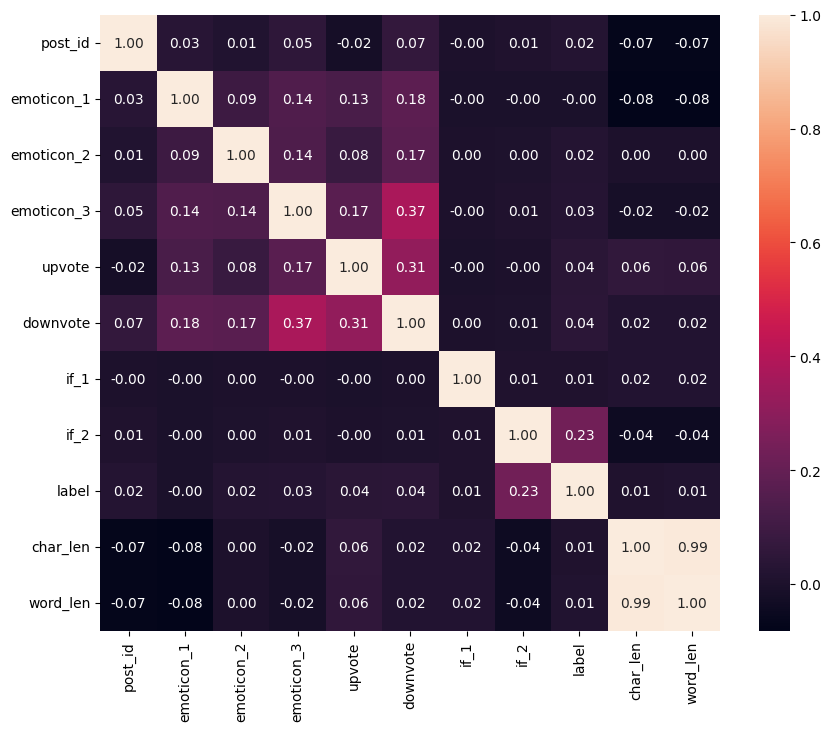

In [87]:
num_cols = train.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,8)) 
corr =num_cols.corr()
sns.heatmap(corr,annot=True,fmt='.2f')

1. char_len and word_len are extremly correlated(0.99)
2. label is very low relation with all features.The strongest link it with if_2(0.23)
3. downvote is  moderatedly correlated with emoticons3(0.37)

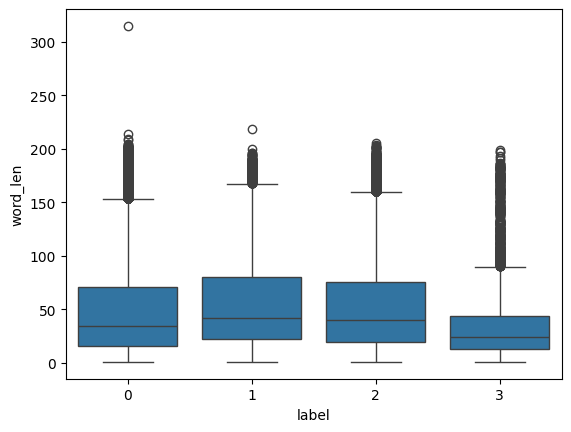

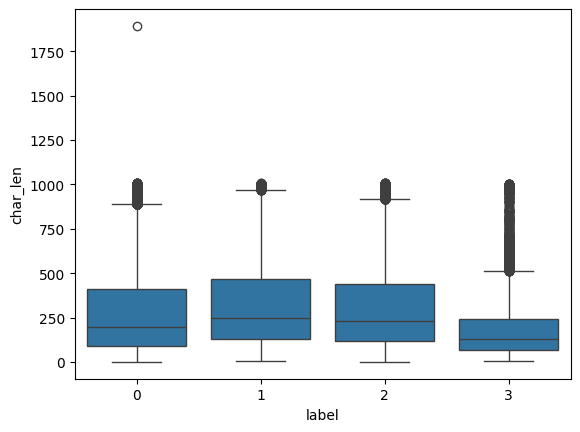

In [88]:
sns.boxplot(x='label', y='word_len', data=train)
plt.show()
sns.boxplot(x='label', y='char_len', data=train)
plt.show()

# 4. Preprocessing for train-validation

In [89]:
from sklearn.model_selection import train_test_split

x = train.drop('label', axis=1)
y = train['label']

x_train, x_val, y_train, y_val = train_test_split(x, y,test_size=0.2,stratify=y,random_state=42)

## III. Handling null value

In [90]:
cols = ['race','religion','gender']
for col in cols:
    for df in (x_train,x_val):
        df[col] = df[col].fillna('unknown')

## IV. Feature Construction

In [91]:
for df in (x_train,x_val):
    df['emoticon_total'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']
    df['upvote_log'] = np.log1p(df['upvote'])       
    df['downvote_log'] = np.log1p(df['downvote'])
    df['upvote_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['log_ratio'] = df['upvote_log'] - df['downvote_log']
    df['char_len'] = df['comment'].str.len()                        
    df['word_len'] = df['comment'].str.split().apply(len)
    df['avg_word_len'] = df['char_len']/(df['word_len']+1)
    dt = pd.to_datetime(df['created_date'], utc=True, errors='coerce')
    df['year'] = dt.dt.year.fillna(-1).astype(int).astype(str)
    df['month'] = dt.dt.month.fillna(-1).astype(int).astype(str)
    df['dayofweek'] = dt.dt.dayofweek.fillna(-1).astype(int).astype(str)
    df['hour'] = dt.dt.hour.fillna(-1).astype(int).astype(str)

## V. Scaling of Numerical feature

In [92]:
num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3',
            'if_1', 'if_2', 'emoticon_total', 'upvote_log', 'downvote_log',
            'upvote_ratio', 'log_ratio','avg_word_len']
scaler = StandardScaler()
x_train_num_scaled = scaler.fit_transform(x_train[num_cols])
x_val_num_scaled = scaler.transform(x_val[num_cols])


## VI. Encoding 

In [93]:
for df in  (x_train,x_val):
    df['post_id'] = df['post_id'].astype(str)
    
cat_cols = ['race', 'religion', 'gender', 'disability', 'post_id',
            'year', 'month', 'dayofweek', 'hour']
    
ohe =OneHotEncoder(handle_unknown='ignore',sparse_output=True)
x_cat_train = ohe.fit_transform(x_train[cat_cols])
x_cat_val = ohe.transform(x_val[cat_cols])

## VII Text Cleaning of the ‘comment’ Column

In [94]:
for df in (x_train,x_val):
    df['comment'] = df['comment'].str.strip()
    df['comment'] = df['comment'].str.replace(r'\s+', ' ', regex=True)
    df['comment'] = df['comment'].str.lower()
    df['comment'] = df['comment'].str.replace(r'http\S+|www\S+', '', regex=True)
    df['comment'] = df['comment'].apply(lambda x: "no_comment" if x.strip() == "" else x)

## VI. Text feature extraction using TF-IDF

In [95]:
tfidf =TfidfVectorizer(max_features=40000,ngram_range=(1,2),stop_words='english',min_df=3,max_df=0.8,sublinear_tf=True)
x_text_train = tfidf.fit_transform(x_train['comment'])
x_text_val = tfidf.transform(x_val['comment'])

## VIII. conversion of numerical columns to sparse matrix

In [96]:

x_num_train = csr_matrix(x_train[num_cols].values)
x_num_val =csr_matrix(x_val[num_cols].values)

## IX. Feature Concatenation using Sparse Matrix

In [97]:
x_train_final = hstack([x_cat_train,x_text_train,x_train_num_scaled])
x_val_final = hstack([x_cat_val,x_text_val,x_val_num_scaled])

In [98]:
# models = {"LGBMClassifier":LGBMClassifier(),"XGBClassifier":XGBClassifier(),
#          "Logistic_regression":LogisticRegression(max_iter=1000, class_weight='balanced'),
#          }
# res =[]
# for name,model in models.items():
#     model.fit(x_train_final,y_train)
#     preds = model.predict(x_val_final)
#     f1 =f1_score(y_val, preds, average='macro')
#     accuracy =accuracy_score(y_val, preds)
#     res.append({"model":name,"f1_score":f1,"accuracy":accuracy})
# res_df = pd.DataFrame(res)
# res_df.head()


### result:

| Model              | f1_score   | accuracy | 
|--------------------|-------------:|---------:|
| LGBGClassifier      |    0.7987  | 0.9111  |  
| Logistic_regression       |        0.7933  |  0.8984    |   
| XGBClassifier       | 0.7779  | 0.8983     |
 
  

### Here lgbm is the best performer with f1_score of 0.7975 whereas sdg is the worst perfomer with f1_score 0.6717.Logistic regression is as good as lgbm.

# 5. Hyperparameter tuning on the best 2 models

## I. LGBMClassifier	

In [99]:
# param_grid_lgb = {
#     'n_estimators': [500,1000],
#     'learning_rate': [0.03,0.05],
#     'num_leaves': [128],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8]
# }

# lgb_model = LGBMClassifier(
#     objective='multiclass',
#     num_class=4,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1
# )

# grid_lgb = GridSearchCV(
#     lgb_model,
#     param_grid_lgb,
#     scoring='f1_macro',
#     cv=2,
#     verbose=0
# )
# grid_lgb.fit(x_train_final, y_train)
# grid_lgb.best_params_

### Best parameter : 
1. colsample: 0.8,
2. learning_rate: 0.03
3. n_estimators: 500,
4. num_leaves: 128,
5. subsample: 0.8

In [100]:
# best_lgbm = grid_lgb.best_estimator_
# y_pred = best_lgbm.predict(x_test_final)
# f1 =f1_score(y_val, preds, average='macro')
# accuracy =accuracy_score(y_val, preds)
# print(f"f1_score:{f1}")
# print(f"accuracy:{accuracy}")

Result:
1. f1: 0.81617
2. accuracy: 0.91638

### Hyperparemeter tuning is giving more accurate result than without tuning 

## II. Logistic Regression

In [101]:
# param_grid_lr = {
#     'C': [0.5, 1, 2],
#     'solver': ['lbfgs']
# }

# lr_model = LogisticRegression(
#     max_iter=1000,
#     class_weight='balanced'
# )

# grid_lr = GridSearchCV(
#     lr_model,
#     param_grid_lr,
#     scoring='f1_macro',
#     cv=3,
#     verbose=0
# )

# grid_lr.fit(x_train_final, y_train)
# grid_lr.best_params_

In [102]:
# param_dist = {
#     'C':       loguniform(0.01, 100),
#     'solver':  ['saga'],
#     'penalty': ['l1', 'l2'],
#     'tol':     [1e-3, 5e-3, 1e-2],
# }

# lr = LogisticRegression(
#     max_iter=1000,
#     class_weight='balanced'
# )

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# search = RandomizedSearchCV(
#     lr,
#     param_distributions=param_dist,
#     n_iter=25,
#     scoring='f1_macro',
#     cv=cv,
#     n_jobs=-1,
#     verbose=2,
#     random_state=42,
#     return_train_score=True,
#     error_score='raise'
# )

# search.fit(x_train_final, y_train)

# print("Best Params:", search.best_params_)
# print("Best F1 Macro:", round(search.best_score_, 4))

Best_param :
1. c=2,
2. solver=lbfgs

In [103]:
# preds = grid_lr.predict(x_val_final)
# f1 =f1_score(y_val, preds, average='macro')
# accuracy =accuracy_score(y_val, preds)
# print(f"f1_score:{f1}")
# print(f"accuracy:{accuracy}")

score without tuning :
1. f1_score: 0.795
2. accuracy: 0.899

score after tuning : 
1. f1_score: 0.79345
2. accuracy: 0.8990

### In the case of Logistic Regression score decreased after HPT


# 6. Preprocessing for train and test

## I. Handling null value

In [104]:
cols = ['race','religion','gender']
for col in cols:
    for df in (train,test):
        df[col] = df[col].fillna('unknown')
train = train.dropna()

In [105]:
y_train =train['label']
x_train = train.drop('label',axis=1)

## II. Feature Costruction

In [106]:
for df in (x_train,test):
    df['emoticon_total'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']
    df['upvote_log'] = np.log1p(df['upvote'])       
    df['downvote_log'] = np.log1p(df['downvote'])
    df['upvote_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['log_ratio'] = df['upvote_log'] - df['downvote_log']
    df['char_len'] = df['comment'].str.len()                        
    df['word_len'] = df['comment'].str.split().apply(len)
    df['avg_word_len'] = df['char_len']/(df['word_len']+1)
    dt = pd.to_datetime(df['created_date'], utc=True, errors='coerce')
    df['year'] = dt.dt.year.fillna(-1).astype(int).astype(str)
    df['month'] = dt.dt.month.fillna(-1).astype(int).astype(str)
    df['dayofweek'] = dt.dt.dayofweek.fillna(-1).astype(int).astype(str)
    df['hour'] = dt.dt.hour.fillna(-1).astype(int).astype(str)

## III. Scaling of numerical features

In [107]:
num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3',
            'if_1', 'if_2', 'emoticon_total', 'upvote_log', 'downvote_log',
            'upvote_ratio', 'log_ratio','avg_word_len']
scaler = StandardScaler()
x_train_num_scaled = scaler.fit_transform(x_train[num_cols])
x_val_num_scaled = scaler.transform(test[num_cols])


## IV. Encoding 

In [108]:
x_train.isnull().sum()

created_date      0
post_id           0
emoticon_1        0
emoticon_2        0
emoticon_3        0
upvote            0
downvote          0
if_1              0
if_2              0
race              0
religion          0
gender            0
disability        0
comment           0
char_len          0
word_len          0
emoticon_total    0
upvote_log        0
downvote_log      0
upvote_ratio      0
log_ratio         0
avg_word_len      0
year              0
month             0
dayofweek         0
hour              0
dtype: int64

In [109]:
for df in  (x_train,test):
    df['post_id'] = df['post_id'].astype(str)
    
cat_cols = ['race', 'religion', 'gender', 'disability', 'post_id',
            'year', 'month', 'dayofweek', 'hour']
ohe =OneHotEncoder(handle_unknown='ignore',sparse_output=True)
x_cat_train = ohe.fit_transform(x_train[cat_cols])
x_cat_test = ohe.transform(test[cat_cols])


## V. Text cleaning of "comment" column

In [110]:
for df in (x_train,test):
    df['comment'] = df['comment'].str.strip()
    df['comment'] = df['comment'].str.replace(r'\s+', ' ', regex=True)
    df['comment'] = df['comment'].str.lower()
    df['comment'] = df['comment'].str.replace(r'http\S+|www\S+', '', regex=True)
    df['comment'] = df['comment'].apply(lambda x: "no_comment" if x.strip() == "" else x)

## VI. Text feature extraction using TF-IDF

In [111]:
tfidf =TfidfVectorizer(max_features=40000,ngram_range=(1,2),stop_words='english',min_df=3,max_df=0.8,sublinear_tf=True)
x_text_train = tfidf.fit_transform(x_train['comment'])
x_text_test = tfidf.transform(test['comment'])

## VII.  convesion of numerical columns to sparse matrix

In [112]:
x_num_train = csr_matrix(x_train[num_cols].values)
x_num_test =csr_matrix(test[num_cols].values)

## VIII. Feature concatination using sparse matrix

In [113]:
x_train_final = hstack([x_cat_train,x_text_train,x_num_train])
x_test_final = hstack([x_cat_test,x_text_test,x_num_test])

# 7. Training model on full dataset with best param

In [114]:
# model = LGBMClassifier(**grid_lgb.best_params_)
# model.fit(x_train_final, y_train)
# test_pred = model.predict(x_test_final)

NameError: name 'grid_lgb' is not defined

In [115]:
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=160,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

logreg = LogisticRegression(
    max_iter=1500,
    class_weight='balanced',
    solver='lbfgs'
)
lgbm.fit(x_train_final, y_train)
logreg.fit(x_train_final, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1500)

In [117]:
offsets = np.array([-0.40, -0.25, -0.15, 0.0])
test_scores = (
    0.7 * np.log(np.clip(lgbm.predict_proba(x_test_final), 1e-9, 1.0)) +
    0.3 * np.log(np.clip(logreg.predict_proba(x_test_final), 1e-9, 1.0))
)

test_pred = (test_scores + offsets).argmax(axis=1)

submission = sample.copy()
submission['label'] = test_pred
submission.to_csv('submission.csv', index=False)


In [ ]:
submission = sample.copy()
submission['label'] = test_pred
submission.to_csv('submission.csv',index=False)

In [118]:
submission.head()

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


## Milestone 1

In [ ]:
# What is the shape of the training dataset?
train_df.shape

In [ ]:
# How many columns are present in the test dataset?
test_df.shape[1]

In [ ]:
# How many columns in the training dataset have object data type?
# How many numerical columns are present in the training dataset?
# Which of the following columns is of boolean type?
train_df.info()

In [ ]:
# Which of the following columns have missing values?
train_df.isnull().sum()


In [ ]:
# How many distinct target classes are present in the dataset?
train_df['label'].unique()

In [ ]:
# What percentage of the dataset approximately belongs to label 0?
((train_df[train_df['label']==0]).shape[0]/(train_df.shape[0]))*100

In [ ]:
# What is the median number of upvotes per comment?
train_df['upvote'].median()

In [ ]:
# Which numerical feature shows the largest maximum value?
for col in ("upvote","downvote","if_1","if_2"):
    print(col ,train_df[col].max())

In [ ]:
# What is the minimum value of if_2?
train_df['if_2'].min()

## Milestone 2

In [ ]:
train_df.head()

In [ ]:
# In the context of text preprocessing for NLP, which condition must be checked in addition to NaN values 
# when assessing missingness in the comment column of train.csv?

In [ ]:
# Convert the created_date column into datetime objects. Identify the month that occurs the most number of
# times in the dataset and enter the answer as a lowercase string
train_df['created_date'] = pd.to_datetime(train_df['created_date'])
train_df['month'] = train_df['created_date'].dt.month_name()
train_df['month'].value_counts().idxmax()

In [ ]:
# Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3
# for each row. What is the maximum value observed in this new feature across the entire dataset?
train_df['total_emoticons'] = train_df['emoticon_1'] + train_df['emoticon_2'] + train_df['emoticon_3']
train_df['total_emoticons'].max()

In [ ]:
# Calculate the median character length (including spaces) of the comment column for all entries where label is
# equal to 3. (Note: Treat any missing comments as empty strings).
train_df['comment'] = train_df['comment'].fillna('')
train_df[train_df['label']==3]['comment'].apply(len).median()

In [ ]:
# If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the 
# resulting scaled value for an observation that originally had exactly 10 upvotes?
mini = train_df['upvote'].min()
maxi =train_df['upvote'].max()
scaled = (10-mini)/(maxi-mini)
scaled

In [ ]:
# What is the average word count (number of words separated by whitespace) for comments that are assigned 
# a label of 1? (Round your answer to 2 decimal places).

word_counts = train_df[train_df['label']==1]['comment'].apply(lambda x: len(x.split()))
avg = word_counts.mean()
avg

In [ ]:
# How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive
count = train_df['comment'].str.contains('Trump', case=False, na=False).sum()
print(count)

In [ ]:
# Take the comment at the very first row (index 0).

# - Remove all punctuation.

# - Consider the following words as stop words and remove the same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# How many words are left in the text after these two operations?
text =train_df.loc[0,'comment']
text = text.translate(str.maketrans('', '', string.punctuation))
text = text.lower()
stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of',
              'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on',
              'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were',
              'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does',
              'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her',
              'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom',
              'i', 'me', 'my', 'we', 'our', 'you', 'your']
words = text.split()
filtered = [ word for word in words if word not in stop_words]
len(filtered)

In [ ]:
# Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number 
# of unique tokens in the dataset and enter the value
tokens = train_df['comment'].str.lower().str.split()
all_tokens = [token for sublist in tokens for token in sublist]
unique_tokens = set(all_tokens)

print(len(unique_tokens))

In [ ]:
# Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df 
# as 5 and ngram_range as (1,2).
# How many TF-IDF features are generated using this configuration? 
vectorizar =TfidfVectorizer(stop_words="english",min_df=5,ngram_range=(1,2))
X = vectorizar.fit_transform(train_df['comment'])
num_features = len(vectorizar.get_feature_names_out())
print(num_features)

## Milestone 3

In [ ]:
from sklearn.model_selection import train_test_split

X=train_df.drop("label", axis=1)
y =train_df["label"]

X_train, X_val, y_train,y_val= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

a=X_train.shape[0]
c =X_val.shape[0]

print(a + c)

In [ ]:
X_train["created_date"]= pd.to_datetime(X_train["created_date"])
X_train["month"] =X_train["created_date"].dt.month
most_frequent_month = X_train["month"].mode()[0]
most_frequent_month

In [ ]:
cat_cols = X_train.select_dtypes(include="object").columns

X_train[cat_cols] =X_train[cat_cols].fillna("none")
X_val[cat_cols] =X_val[cat_cols].fillna("none")

ohe_cols= ["religion", "gender", "race"]

encoder= OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_train= encoder.fit_transform(X_train[ohe_cols])
encoded_val =encoder.transform(X_val[ohe_cols])

encoded_train_df =pd.DataFrame( encoded_train, columns=encoder.get_feature_names_out(ohe_cols),index=X_train.index)

encoded_val_df =pd.DataFrame(encoded_val,columns=encoder.get_feature_names_out(ohe_cols),index=X_val.index)

X_train= pd.concat([X_train.drop(columns=ohe_cols), encoded_train_df], axis=1)
X_val =pd.concat([X_val.drop(columns=ohe_cols), encoded_val_df], axis=1)

X_train.shape

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer= CountVectorizer()
X_train_counts= vectorizer.fit_transform(X_train["comment"])
X_val_counts= vectorizer.transform(X_val["comment"])
sum_counts= X_train_counts[1].sum()
sum_counts

In [ ]:
X_train["disability"] = X_train["disability"].map({True: 1, False: 0}).astype(int)
X_val["disability"] = X_val["disability"].map({True: 1, False: 0}).astype(int)
total_sum = X_train["disability"].sum() + X_val["disability"].sum()
total_sum

In [ ]:
from sklearn.preprocessing import StandardScaler

datetime_cols = X_train.select_dtypes(include=["datetime64[ns]", "datetime64"]).columns
X_train = X_train.drop(columns=datetime_cols)
X_val = X_val.drop(columns=datetime_cols)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])
scaler.n_features_in_

In [ ]:
X =train_df.drop("label", axis=1)
y =train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer=SimpleImputer(strategy="most_frequent")

X_train =pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns,index=X_train.index)

X_val =pd.DataFrame(imputer.transform(X_val), columns=X_val.columns,index=X_val.index)

X_train= X_train.applymap(lambda x: abs(x) if isinstance(x, (int, float)) else x)
X_val= X_val.applymap(lambda x: abs(x) if isinstance(x, (int, float)) else x)

X_train["created_date"] = pd.to_datetime(X_train["created_date"])
X_val["created_date"] = pd.to_datetime(X_val["created_date"])

for df in [X_train, X_val]:
    df["day"] = df["created_date"].dt.day
    df["month"] = df["created_date"].dt.month
    df["year"] = df["created_date"].dt.year

X_train=X_train.drop(columns=["created_date", "comment"])
X_val = X_val.drop(columns=["created_date", "comment"])

cat_cols =X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

X_train_cat =encoder.fit_transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])

X_train= X_train.drop(columns=cat_cols)
X_val= X_val.drop(columns=cat_cols)

X_train_num= csr_matrix(X_train.values.astype(float))
X_val_num = csr_matrix(X_val.values.astype(float))

X_train_final= hstack([X_train_num, X_train_cat])
X_val_final= hstack([X_val_num, X_val_cat])

model = MultinomialNB()
model.fit(X_train_final, y_train)

y_train_pred =model.predict(X_train_final)

macro_f1 = f1_score(y_train, y_train_pred, average="macro")

macro_f1

In [ ]:
from sklearn.metrics import f1_score

y_val_pred= model.predict(X_val_final)
macro_f1_val= f1_score(y_val, y_val_pred, average="macro")
macro_f1_val

## Milestone 4

## Milestone 5